# Parameter selection example - PICO

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from parameter_selection_toolbox import *

# Settings

In [3]:
# Directories
figure_dir = 'figures'
data_path="/media/NAS2/ISMIP7/share_with_modellers"
ensemble_path="/media/NAS2/pism_out/"

# Constants
yearlen = 365.14*24*60*60 # seconds per year
ice_density = 918 # kg/m3
reso=8000 # m model resolution used for melt parameterisation [m]


# parameterisation ensemble table 
p1_name = 'ocean.pico.overturning_coefficent'
p2_name = 'ocean.pico.heat_exchange_coefficent'

pism_present_day_ensemble = "pism_16_ismip7_picotest_zhou_initmip8km"
pism_mathiot_cold_ensemble = "pism_16_ismip7_picotest_Mathiot_cold_initmip8km"
pism_mathiot_warm_ensemble = "pism_16_ismip7_picotest_Mathiot_warm_initmip8km"

pism_timmermann_cold_ensemble = "pism_16_ismip7_picotest_Timmermann_cold_initmip8km"
pism_timmermann_warm_ensemble = "pism_16_ismip7_picotest_Timmermann_warm_initmip8km"

ensemble_table = pd.read_csv('./'+pism_present_day_ensemble+'.txt',
                                 sep=r'\s+',index_col=0)
ensemble_table

,ocean.pico.overturning_coefficent,ocean.pico.heat_exchange_coefficent
hash,,
117638c5,10000.0,0.000001
61bc631f,10000.0,0.000005
b7ba74fd,10000.0,0.000010
6f6b7091,10000.0,0.000015
49c075df,10000.0,0.000020
...,...,...
ccd1fc05,20000000.0,0.000045
21eb55f8,20000000.0,0.000050
69a82bbf,20000000.0,0.000075


# Load data

In [6]:
# Load ensembles

pd_ensemble = xr.load_dataset('Ensemble_'+pism_present_day_ensemble+'_optimaldeltaT_pm07.nc', drop_variables=['timestamp'])
mathiot_cold_ensemble = xr.load_dataset('Ensemble_'+pism_mathiot_cold_ensemble+'_optimaldeltaT_pm07.nc', drop_variables=['timestamp'])
mathiot_warm_ensemble = xr.load_dataset('Ensemble_'+pism_mathiot_warm_ensemble+'_optimaldeltaT_pm07.nc', drop_variables=['timestamp'])
timmermann_cold_ensemble = xr.load_dataset('Ensemble_'+pism_timmermann_cold_ensemble+'_optimaldeltaT_pm07.nc', drop_variables=['timestamp'])
timmermann_warm_ensemble = xr.load_dataset('Ensemble_'+pism_timmermann_warm_ensemble+'_optimaldeltaT_pm07.nc', drop_variables=['timestamp'])


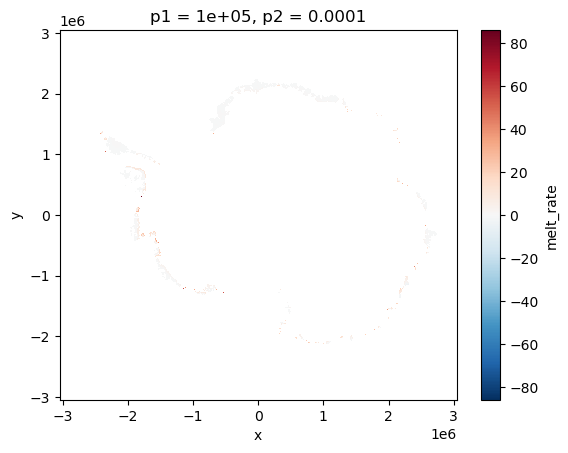

In [7]:
pd_ensemble.sel(p1=1e5,p2=10e-5).melt_rate.plot() # .optimal_deltaT_per_basin


#invalid = pd_ensemble.where(pd_ensemble.optimal_deltaT_per_basin!=np.nan)

In [8]:
pd_ensemble["invalid"] = np.isnan(pd_ensemble.optimal_deltaT_per_basin.mean('basin', skipna=False))

In [10]:
# convert melt rates to kg/m2/a

pd_ensemble['melt_rate'] = pd_ensemble['melt_rate']*ice_density
mathiot_cold_ensemble['melt_rate'] = mathiot_cold_ensemble['melt_rate']*ice_density
mathiot_warm_ensemble['melt_rate'] = mathiot_warm_ensemble['melt_rate']*ice_density
timmermann_cold_ensemble['melt_rate'] = timmermann_cold_ensemble['melt_rate']*ice_density
timmermann_warm_ensemble['melt_rate'] = timmermann_warm_ensemble['melt_rate']*ice_density

In [11]:
# Supporting Data

# Load imbie2 basins as used on ISMIP
basins = xr.load_dataset(os.path.join(data_path, 'imbie2', "basin_numbers_ismip8km_v2.nc"))
basins = basins.rename({'basinNumber':'basins'})
nBasins = int(basins.basins.max())

# present-day melting, melt rates from Paolo et al., 2023, error estimates combined from Paolo and Adusumilli et al., 2020
melt_obs = xr.load_dataset(os.path.join(data_path, 'parameterisations','melt_paolo_err_adusumilli_ismip8km.nc')) # Field
MeltDataImbie = pd.read_csv(os.path.join(data_path, 'parameterisations','Melt_Paolo_Err_Adusumilli_imbie2_v2.csv'), index_col=0) # Aggregated per imbier basin

# Buttressing Flux Response Numbers, remapped to 8km 
bfrn = xr.load_dataset(os.path.join(data_path,'parameterisations',"BFRN_ismip8km_v2.nc"))
nBins = 10

In [12]:
bed = xr.load_dataset(os.path.join(data_path, 'topography', 'bedmap3_ismip_8km.nc'))
mask = bed.floating_frac>0.5

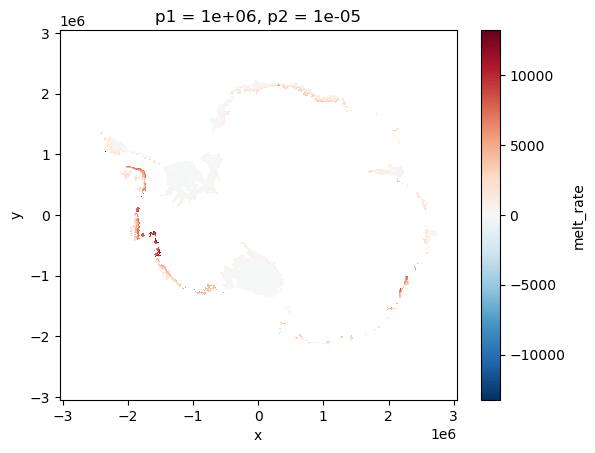

In [13]:
pd_ensemble.sel(p1=1e6,p2=1e-5).melt_rate.plot()

# Optimise

In [15]:
sample_size=10000

optimise ="all" # "term1", ..
term2_spec="aggregate" # "average" # "aggregate"
term3_spec="average" # "average", "aggregate"
term3_opt="anomaly" # "both", "anomaly"
w3_spec="none" # "only_cold", "only_warm", works only with "both", "timmermann", "mathiot"
w3_only_basin= "false" #"9" #"false" # 9 for ASE in mathiot data, otherwise put "false" 
average_as="true" # no big effect, can be "true" or "false"

min_p1, min_p2, a1,a2,a3 = calculate_objective_function(optimise,
    term2_spec,term3_spec,term3_opt, w3_spec,w3_only_basin,
    sample_size, average_as,
    basins['basins'], basins['basins'],
    mask, mask,
    bfrn, bfrn, reso, melt_obs, MeltDataImbie, data_path, 
    pd_ensemble, mathiot_cold_ensemble, mathiot_warm_ensemble, 
    mathiot_cold_ensemble, mathiot_warm_ensemble)
    #timmermann_cold_ensemble, timmermann_warm_ensemble)


Calculate Term 1
Calculate Term 2
Calculate Term 3
Sampling, this might take a moment...


# Analyse parameter distribution

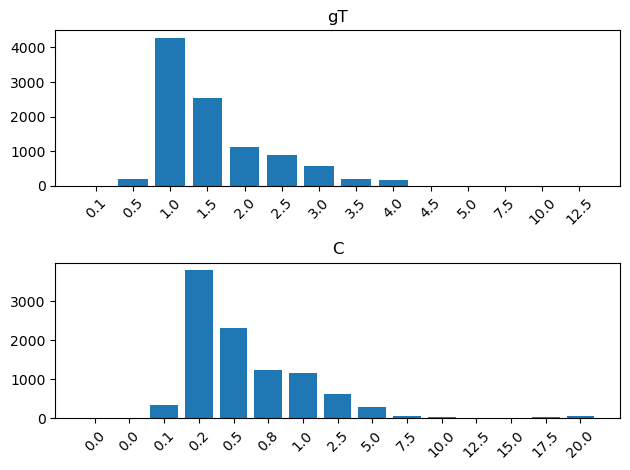

In [16]:
fig,axes = plt.subplots(2,1, sharex=False, sharey=False)
ax = axes.flatten()[0]

bin_edges = np.array( np.append(pd_ensemble.p2.values[0]*0.5, pd_ensemble.p2.values+1e-7) )
counts, _ = np.histogram(np.array(min_p2), bins= bin_edges)
positions = np.arange(len(counts))
ax.bar(positions, counts, width=0.8)
labels = np.round(pd_ensemble.p2.values*1e5, 1)
ax.set_xticks(positions, labels, rotation=45)
ax.set_title('gT')

ax = axes.flatten()[1]
bin_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+0.001e6) )
counts, _ = np.histogram(np.array(min_p1), bins= bin_edges)
positions = np.arange(len(counts))
ax.bar(positions, counts, width=0.8)
labels = np.round(pd_ensemble.p1.values/1e6, 1)
ax.set_xticks(positions, labels, rotation=45)
ax.set_title('C')
plt.tight_layout()

#plt.savefig(os.path.join(figure_dir,pism_present_day_ensemble+'_Hists_Sample'+str(sample_size)+'.png'))

<Figure size 640x480 with 0 Axes>

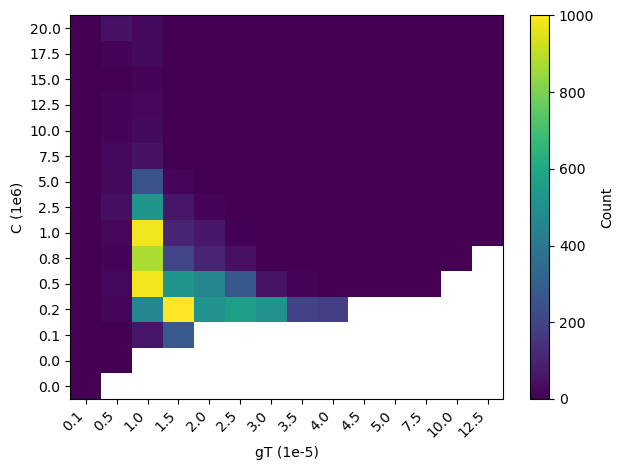

In [18]:
fig,axes = plt.subplots(1,1, sharex=False, sharey=False)
ax = axes

x_edges = np.array( np.append(pd_ensemble.p2.values[0]*0.5, pd_ensemble.p2.values+1e-7) )
y_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+0.001e6) )
counts, _, _ = np.histogram2d(min_p2,np.array(min_p1), bins=[x_edges, y_edges])
plt.clf()

fig, ax = plt.subplots()

counts_masked = np.ma.masked_where(pd_ensemble.invalid.values==True, counts.T)

im = ax.pcolormesh(np.arange(len(x_edges)), np.arange(len(y_edges)), 
                    #counts.T, cmap='viridis', shading='auto', vmin=0 #, vmax=1000
                    counts_masked, cmap='viridis', shading='auto', vmin=0 , vmax=1000
                  )

y_labels = np.round(pd_ensemble.p1.values/1e6, 1)
x_labels = np.round(pd_ensemble.p2.values*1e5, 1)

# Set tick positions and labels
ax.set_xticks(np.arange(len(x_labels))+0.5)
ax.set_yticks(np.arange(len(y_labels))+0.5)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_yticklabels(y_labels)

ax.set_ylabel("C (1e6)")
ax.set_xlabel("gT (1e-5)")
plt.colorbar(im, label='Count')
plt.tight_layout()

#plt.savefig(os.path.join(figure_dir,pism_present_day_ensemble+'_Hist2D_Sample'+str(sample_size)+'_all.png'))    

<Figure size 640x480 with 0 Axes>

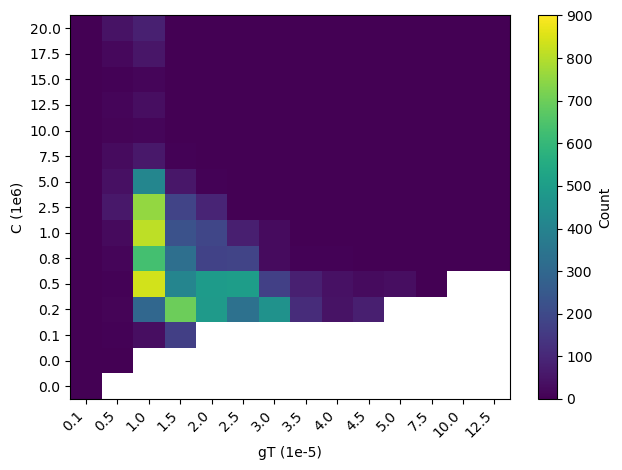

In [26]:
fig,axes = plt.subplots(1,1, sharex=False, sharey=False)
ax = axes

x_edges = np.array( np.append(pd_ensemble.p2.values[0]*0.5, pd_ensemble.p2.values+1e-7) )
y_edges = np.array( np.append(pd_ensemble.p1.values[0]*0.5, pd_ensemble.p1.values+0.001e6) )
counts, _, _ = np.histogram2d(min_p2,np.array(min_p1), bins=[x_edges, y_edges])
plt.clf()

fig, ax = plt.subplots()

counts_masked = np.ma.masked_where(pd_ensemble.invalid.values==True, counts.T)

im = ax.pcolormesh(np.arange(len(x_edges)), np.arange(len(y_edges)), 
                    #counts.T, cmap='viridis', shading='auto', vmin=0 #, vmax=1000
                    counts_masked, cmap='viridis', shading='auto', vmin=0 , vmax=900
                  )

y_labels = np.round(pd_ensemble.p1.values/1e6, 1)
x_labels = np.round(pd_ensemble.p2.values*1e5, 1)

# Set tick positions and labels
ax.set_xticks(np.arange(len(x_labels))+0.5)
ax.set_yticks(np.arange(len(y_labels))+0.5)
ax.set_xticklabels(x_labels, rotation=45, ha='right')
ax.set_yticklabels(y_labels)

ax.set_ylabel("C (1e6)")
ax.set_xlabel("gT (1e-5)")
plt.colorbar(im, label='Count')
plt.tight_layout()

#plt.savefig(os.path.join(figure_dir,pism_present_day_ensemble+'_Hist2D_Sample'+str(sample_size)+'_all.png'))    

# Select parameters

tbc

# Analyse parameters

In [27]:
C = 0.5e6
gT = 1.0e-5

In [28]:
result_ds = pd_ensemble.sel(p1=C, p2=gT)

Text(0.5, 1.0, 'Present-day melt rates')

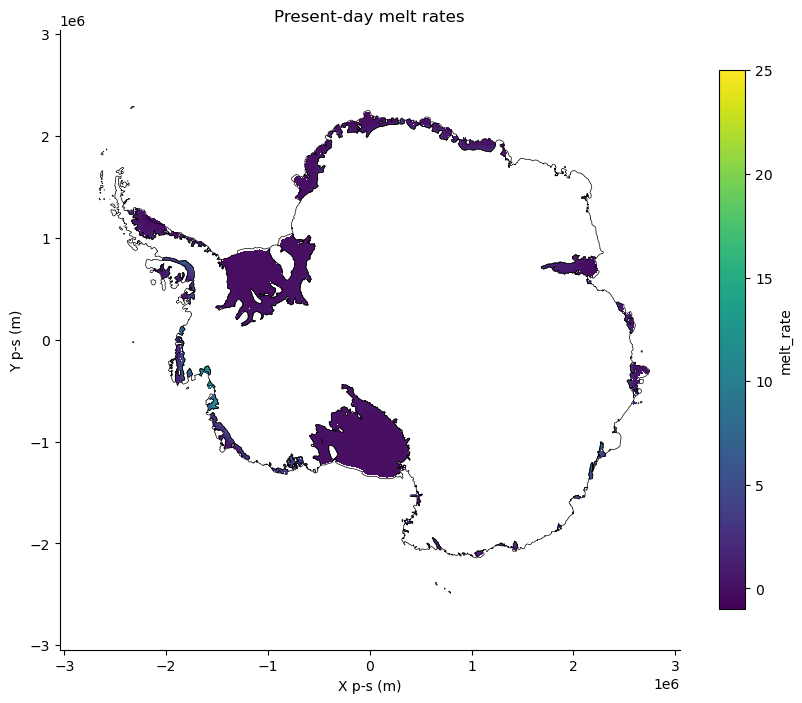

In [29]:
plt.figure(figsize=(10,10))

(result_ds.melt_rate/ice_density).plot( vmin=-1, vmax=25, cmap='viridis',cbar_kwargs={'shrink': 0.7} )
ax = plt.gca()
ax.set_aspect('equal')
ax.set_xlabel('X p-s (m)')
ax.set_ylabel('Y p-s (m)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.contour(result_ds.x, result_ds.y, bed.ocean_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.contour(result_ds.x, result_ds.y, bed.floating_frac,levels=[0.5], colors=['black'], linewidths=0.5)
plt.title('Present-day melt rates')

#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_pdmelt.png'))  

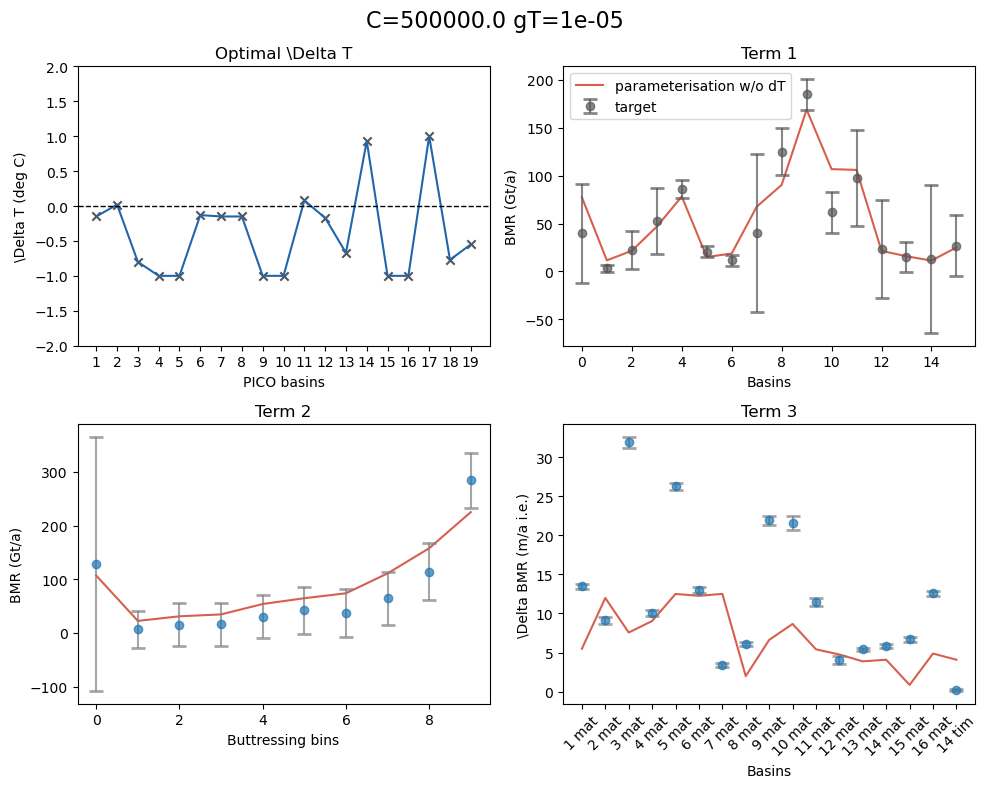

In [31]:
# Basic 2x2 grid

mask_m = mask
basins_m = basins
bfrn_m = bfrn

cvt = 8000**2  / 1e12  # to convert to Gt/a
cvt_m = reso**2  / 1e12  # to convert to Gt/a

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

color_deltaT="#2166AC"
color_wocorrection = "#D6604D"
color_wcorrection = "#2166AC"


# Access individual subplots
ax = axes[0, 0]  # Top left
ax.scatter(range(19), result_ds.optimal_deltaT_per_basin, color="#555555", marker='x')
ax.plot(range(19), result_ds.optimal_deltaT_per_basin, color=color_deltaT)
ax.set_ylim([-2,2])
ax.set_ylabel(r'\Delta T (deg C)')
ax.set_xticks(range(19), labels=range(1,20))
ax.set_xlabel('PICO basins')
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_title(r'Optimal \Delta T')

ax = axes[0, 1]  # Top right
t1_model_ndT, t1_obs_ndT, t1_obs_mean_ndT, t1_obs_sigma_ndT = calculate_term1(
    pd_ensemble.sel(p1=C,p2=gT, method='nearest'),mask_m,
    basins_m['basins'],nBasins,cvt_m,MeltDataImbie,1)
#t1_model, t1_obs, t1_obs_mean, t1_obs_sigma = calculate_term1(result_ds,mask_m,
#                                                              basins_m['basins'],
#                                                              nBasins,cvt_m,MeltDataImbie,1)

#ax.plot(range(nBasins+1),t1_model , label='parameterisation', color=color_wcorrection)
ax.plot(range(nBasins+1),t1_model_ndT.values , label='parameterisation w/o dT', color=color_wocorrection)
ax.errorbar(range(nBasins+1), t1_obs_mean_ndT, xerr=None, yerr=t1_obs_sigma_ndT, 
             fmt='o', capsize=5, capthick=2, color="#555555", 
             ecolor="#555555", alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Basins')
#plt.text(0,2, 'Modelled average melt = '+str(np.round(np.sum(t2_model).values))+' m/a' )
#plt.text(0,1, 'Observed average melt = '+str(np.round(np.sum(t2_obs_mean).values))+' m/a' )
ax.legend()
ax.set_title('Term 1')

ax = axes[1, 0]  # Bottom left
t2_model_ndT, t2_obs, t2_weights, t2_obs_mean, t2_obs_sigma = calculate_term2(
    pd_ensemble.sel(p1=C,p2=gT, method='nearest'),mask, mask_m,
    bfrn, bfrn_m,cvt,cvt_m,sample_size,term2_spec,melt_obs)

#t2_model, t2_obs, t2_weights, t2_obs_mean, t2_obs_sigma = calculate_term2(
#    result_ds,mask,mask_m,bfrn,bfrn_m,cvt,cvt_m,sample_size,term2_spec,melt_obs)

#ax.plot(range(nBins),t2_model , label='parameterisation', color=color_wcorrection)
ax.plot(range(nBins),t2_model_ndT.values , label='parameterisation w/o dT', color=color_wocorrection)
ax.errorbar(range(nBins), t2_obs_mean, xerr=None, yerr=t2_obs_sigma, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('BMR (Gt/a)')
ax.set_xlabel('Buttressing bins')
#ax.legend()
ax.set_title('Term 2')


ax = axes[1, 1]  # Bottom right

t3_model_ndT, t3_obs, t3_weights, t3_obs_mean, t3_obs_sigma = calculate_term3(
    pd_ensemble.sel(p1=C,p2=gT, method='nearest'),mathiot_cold_ensemble.sel(p1=C,p2=gT, method='nearest'), 
    mathiot_warm_ensemble.sel(p1=C,p2=gT, method='nearest'),
    mathiot_cold_ensemble.sel(p1=C,p2=gT, method='nearest'), 
    #timmermann_cold_ensemble.sel(p1=C,p2=gT, method='nearest'), 
    mathiot_warm_ensemble.sel(p1=C,p2=gT, method='nearest'),
    #timmermann_warm_ensemble.sel(p1=C,p2=gT, method='nearest'),
    mask,mask_m,basins['basins'],basins_m['basins'],cvt,cvt_m,
    sample_size,term3_spec,term3_opt,w3_spec,
    data_path,nBasins,w3_only_basin)

#t3_model, t3_obs, t3_weights, t3_obs_mean, t3_obs_sigma = calculate_term3(
#    result_ds,result_mathiot_cold, result_mathiot_warm,
#    result_timmermann_cold, result_timmermann_warm,
#    mask, mask_m,basins['basins'],basins_m['basins'],cvt,cvt_m,
#    sample_size,term3_spec,term3_opt,w3_spec,
#    data_path,nBasins,w3_only_basin)

#ax.plot(range(nBasins+2),t3_model/ice_density , label='parameterisation', color=color_wcorrection)
ax.plot(range(nBasins+2),t3_model_ndT.values/ice_density , label='parameterisation w/o dT',color=color_wocorrection)
ax.errorbar(range(nBasins+2), t3_obs_mean/ice_density, xerr=None, yerr=t3_obs_sigma/ice_density, 
             fmt='o', capsize=5, capthick=2,
             ecolor='gray', alpha=0.7, label='target')
ax.set_ylabel('\Delta BMR (m/a i.e.)')
ax.set_xticks(range(nBasins+2))
ax.set_xticklabels(t3_model_ndT.basins.values, rotation=45)
ax.set_xlabel('Basins')
#ax.legend()
ax.set_title('Term 3')

# Add overall title
fig.suptitle('C='+str(C)+' gT='+str(gT), fontsize=16)


# Adjust spacing
plt.tight_layout()


#plt.savefig(os.path.join(figure_dir,'Optimise_quadratic_K'+str(K)+'_Terms.png'))  

In [72]:
t3_model_ndT

<xarray.DataArray 'melt_rate' (basins: 17)> Size: 136B
array([ 6027.38034058, 24451.99658203,  7366.00085449, 11455.54632568,
       22638.92285156, 23810.10595703, 24533.77148438,  1525.80195618,
        8828.14160156, 15131.59960938,  7406.57373047,  5442.32348633,
        4021.80032349,  5152.53416443,   521.84280109,  4497.14305115,
        1583.35681152])
Coordinates:
    p1       float64 8B 2.5e+05
    p2       float64 8B 2.5e-05
  * basins   (basins) <U6 408B '1 mat' '2 mat' '3 mat' ... '16 mat' '14 tim'

# Select parameters
It is not straightforward how to select the 5th and 95th percentile parameters from the PICO ensemble, a look into the sensitivity might help

In [78]:
# Median the most frequent value
C= 0.25e6
gT=2.5e-5

for basin in range(1,20): # Note that these are the PICO basins which are different from the IMBIE ones
    print('Basin ', basin, ':',np.round(pd_ensemble['sensitivity_per_basin'].sel(p1=C,p2=gT,basin=basin).values,2), 'm/a/K')

print('Corresponding deltaT values:', pd_ensemble['optimal_deltaT_per_basin'].sel(p1=C,p2=gT).values)

Basin  1 : 0.24 m/a/K
Basin  2 : 1.41 m/a/K
Basin  3 : 1.23 m/a/K
Basin  4 : 1.86 m/a/K
Basin  5 : 7.31 m/a/K
Basin  6 : 2.05 m/a/K
Basin  7 : 1.69 m/a/K
Basin  8 : 6.74 m/a/K
Basin  9 : 7.33 m/a/K
Basin  10 : 7.51 m/a/K
Basin  11 : 2.83 m/a/K
Basin  12 : 0.24 m/a/K
Basin  13 : 3.58 m/a/K
Basin  14 : 3.92 m/a/K
Basin  15 : 3.77 m/a/K
Basin  16 : 2.24 m/a/K
Basin  17 : 12.75 m/a/K
Basin  18 : 1.38 m/a/K
Basin  19 : 4.33 m/a/K
Corresponding deltaT values: [ 0.5   0.23 -0.5  -0.5  -0.5   0.27 -0.2  -0.5  -0.5  -0.5  -0.02  0.5
 -0.5  -0.15 -0.5  -0.5   0.48 -0.5  -0.5 ]


In [13]:
# For the 5th percentile, two values are possible, either small(est) C and corresponding gammaT, or other way around
# Given the different sensitivities in different basins, it might be worth trying both
C= 0.1e6
gT=2.5e-5
for basin in range(1,20): # Note that these are the PICO basins which are different from the IMBIE ones
    print('Basin ', basin, ':',np.round(pd_ensemble['sensitivity_per_basin'].sel(p1=C,p2=gT,basin=basin).values,2), 'm/a/K')

print('Corresponding deltaT values:', pd_ensemble['optimal_deltaT_per_basin'].sel(p1=C,p2=gT).values)

C= 5e6
gT=0.5e-5
for basin in range(1,20): # Note that these are the PICO basins which are different from the IMBIE ones
    print('Basin ', basin, ':',np.round(pd_ensemble['sensitivity_per_basin'].sel(p1=C,p2=gT,basin=basin).values,2), 'm/a/K')

print('Corresponding deltaT values:', pd_ensemble['optimal_deltaT_per_basin'].sel(p1=C,p2=gT).values)

Basin  1 : 0.11 m/a/K
Basin  2 : 0.5 m/a/K
Basin  3 : 0.75 m/a/K
Basin  4 : 0.8 m/a/K
Basin  5 : 4.45 m/a/K
Basin  6 : 0.57 m/a/K
Basin  7 : 1.78 m/a/K
Basin  8 : 5.31 m/a/K
Basin  9 : 5.25 m/a/K
Basin  10 : 4.93 m/a/K
Basin  11 : 4.77 m/a/K
Basin  12 : 0.11 m/a/K
Basin  13 : 2.41 m/a/K
Basin  14 : 5.17 m/a/K
Basin  15 : 2.03 m/a/K
Basin  16 : 1.36 m/a/K
Basin  17 : 9.71 m/a/K
Basin  18 : 0.82 m/a/K
Basin  19 : 3.03 m/a/K
Corresponding deltaT values: [ 2.    0.83  0.3  -0.83 -1.17  1.2   0.35 -0.   -0.63 -0.85  0.08  2.
 -0.05  1.52 -1.4   0.23  0.7   0.4  -0.25]
Basin  1 : 0.77 m/a/K
Basin  2 : 1.29 m/a/K
Basin  3 : 1.51 m/a/K
Basin  4 : 1.46 m/a/K
Basin  5 : 1.99 m/a/K
Basin  6 : 1.61 m/a/K
Basin  7 : 1.73 m/a/K
Basin  8 : 1.78 m/a/K
Basin  9 : 2.03 m/a/K
Basin  10 : 2.02 m/a/K
Basin  11 : 1.96 m/a/K
Basin  12 : 0.69 m/a/K
Basin  13 : 1.87 m/a/K
Basin  14 : 2.03 m/a/K
Basin  15 : 1.81 m/a/K
Basin  16 : 1.71 m/a/K
Basin  17 : 2.09 m/a/K
Basin  18 : 1.56 m/a/K
Basin  19 : 1.87 m/a/K
Co

In [14]:
# For the 95th percentile, two values are possible, either larg(est) C and corresponding gammaT, or other way around
# Given the different sensitivities in different basins, I would suggest trying both. Or focusig on the relevant regions
# or chose the parameters that yield highest sensitivity in the corresponding region
C= 20e6
gT=1e-5
for basin in range(1,20): # Note that these are the PICO basins which are different from the IMBIE ones
    print('Basin ', basin, ':',np.round(pd_ensemble['sensitivity_per_basin'].sel(p1=C,p2=gT,basin=basin).values,2), 'm/a/K')
print('Corresponding deltaT values:', pd_ensemble['optimal_deltaT_per_basin'].sel(p1=C,p2=gT).values)

# For the 95th percentile, two values are possible, either larg(est) C and corresponding gammaT, or other way around
C= 0.5e6
gT=12.5e-5
for basin in range(1,20): # Note that these are the PICO basins which are different from the IMBIE ones
    print('Basin ', basin, ':',np.round(pd_ensemble['sensitivity_per_basin'].sel(p1=C,p2=gT,basin=basin).values,2), 'm/a/K')
print('Corresponding deltaT values:', pd_ensemble['optimal_deltaT_per_basin'].sel(p1=C,p2=gT).values)

Basin  1 : 1.97 m/a/K
Basin  2 : 2.78 m/a/K
Basin  3 : 3.18 m/a/K
Basin  4 : 2.99 m/a/K
Basin  5 : 3.97 m/a/K
Basin  6 : 3.38 m/a/K
Basin  7 : 3.55 m/a/K
Basin  8 : 4.08 m/a/K
Basin  9 : 4.07 m/a/K
Basin  10 : 4.04 m/a/K
Basin  11 : 3.96 m/a/K
Basin  12 : 1.68 m/a/K
Basin  13 : 3.79 m/a/K
Basin  14 : 4.09 m/a/K
Basin  15 : 3.78 m/a/K
Basin  16 : 3.59 m/a/K
Basin  17 : 4.19 m/a/K
Basin  18 : 3.27 m/a/K
Basin  19 : 3.79 m/a/K
Corresponding deltaT values: [-0.63 -0.48 -1.25 -1.75 -1.25 -0.67 -0.58 -0.35 -0.77 -1.02 -0.05 -0.7
 -1.45  0.98 -2.   -2.    2.   -0.75 -0.65]
Basin  1 : 0.54 m/a/K
Basin  2 : 1.57 m/a/K
Basin  3 : 2.28 m/a/K
Basin  4 : 2.62 m/a/K
Basin  5 : 17.17 m/a/K
Basin  6 : 2.51 m/a/K
Basin  7 : 6.22 m/a/K
Basin  8 : 20.19 m/a/K
Basin  9 : 20.94 m/a/K
Basin  10 : 20.07 m/a/K
Basin  11 : 18.7 m/a/K
Basin  12 : 0.35 m/a/K
Basin  13 : 7.85 m/a/K
Basin  14 : 18.37 m/a/K
Basin  15 : 8.5 m/a/K
Basin  16 : 3.97 m/a/K
Basin  17 : 45.66 m/a/K
Basin  18 : 2.73 m/a/K
Basin  19 : 11.51